# Lecture 6a — Diagnosing an ESG Time Series

**AI-integrated Sustainable Finance (25881) · Spring 2026**

Before you forecast anything, you need to know what your series actually is.
This notebook works through the three diagnostic questions from the lecture:

1. **Which clock is this series on?** Native frequency, publication lag, revision behaviour.
2. **Is the seasonality real, or did my pipeline create it?**
3. **What period does the data itself report, and how much variance sits there?**

Notebook 6b then does the forecasting. Nothing here needs a GPU, and everything
fits comfortably in a 2 GB Binder.

---

### How to read this notebook

Prose sections are written for a finance-first reader. Where the mathematics
matters, it is folded into a collapsible block like the one below — open it if
you want the derivation, skip it if you want the argument.

<details>
<summary><b>Show the maths: what "detrending" is actually doing</b></summary>

A polynomial detrend of order $d$ fits $\hat{x}_t = \sum_{j=0}^{d}\beta_j t^j$
by least squares and analyses the residual $x_t - \hat{x}_t$. This matters for
spectral work because a trend is a very low-frequency component: leaving it in
puts enormous power in the lowest bins, and on a log-period axis that power
smears upward and can swamp a genuine seasonal peak.

</details>

**Exercises** are tiered. **Core** exercises are the ones to do; **Stretch**
exercises are there if you finish early or want the assignment-grade version.

---
## 0. Setup

`esgts6.py` must sit next to this notebook. It handles data loading (local →
cache → GitHub), the Plotly house theme, and the spectral and forecasting
helpers. Everything it does is plain `numpy`/`pandas`; read the source if a
function surprises you.

The first run downloads about 60 MB and caches it. Every run after that is offline.

In [1]:
import numpy as np
import pandas as pd
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from statsmodels.tsa.seasonal import STL

import esgts6 as E

E.use_house_theme()
pd.set_option("display.float_format", lambda v: f"{v:,.3f}")

print("data source:", E.REPO)

data source: https://raw.githubusercontent.com/VitaliAlexeev/AI_SustainableFinance_2026/main/data


---
## 1. Three clocks

The lecture claimed that "carbon data" is not one kind of object. Let us check
that by loading three series that all describe emissions, and looking at what
they have in common. (Answer: almost nothing.)

In [2]:
co2 = E.load_mauna_loa()          # physical clock: monthly, since 1958
nee = E.load_market("NEE")        # market clock: daily, NextEra Energy
owid = E.load_owid()              # reporting clock: annual, country panel

world = owid.query("country == 'World'").set_index("year")["co2"].dropna()
aus = owid.query("country == 'Australia'").set_index("year")["co2"].dropna()

print(f"Mauna Loa   {len(co2):>6} obs  {co2.index.min():%Y-%m} to {co2.index.max():%Y-%m}")
print(f"NextEra     {len(nee):>6} obs  {nee.index.min():%Y-%m-%d} to {nee.index.max():%Y-%m-%d}")
print(f"World CO2   {len(world):>6} obs  {world.index.min()} to {world.index.max()}")

Mauna Loa      821 obs  1958-03 to 2026-07
NextEra       1259 obs  2013-02-08 to 2018-02-07
World CO2      275 obs  1750 to 2024


Look hard at that third line. It is **2026**, and the most recent world
emissions figure in the flagship public dataset is for **2024**.

That gap is not a data-quality problem to be cleaned away. It is the structural
feature that makes ESG forecasting different from forecasting prices, and
almost everything else in this lecture follows from it.

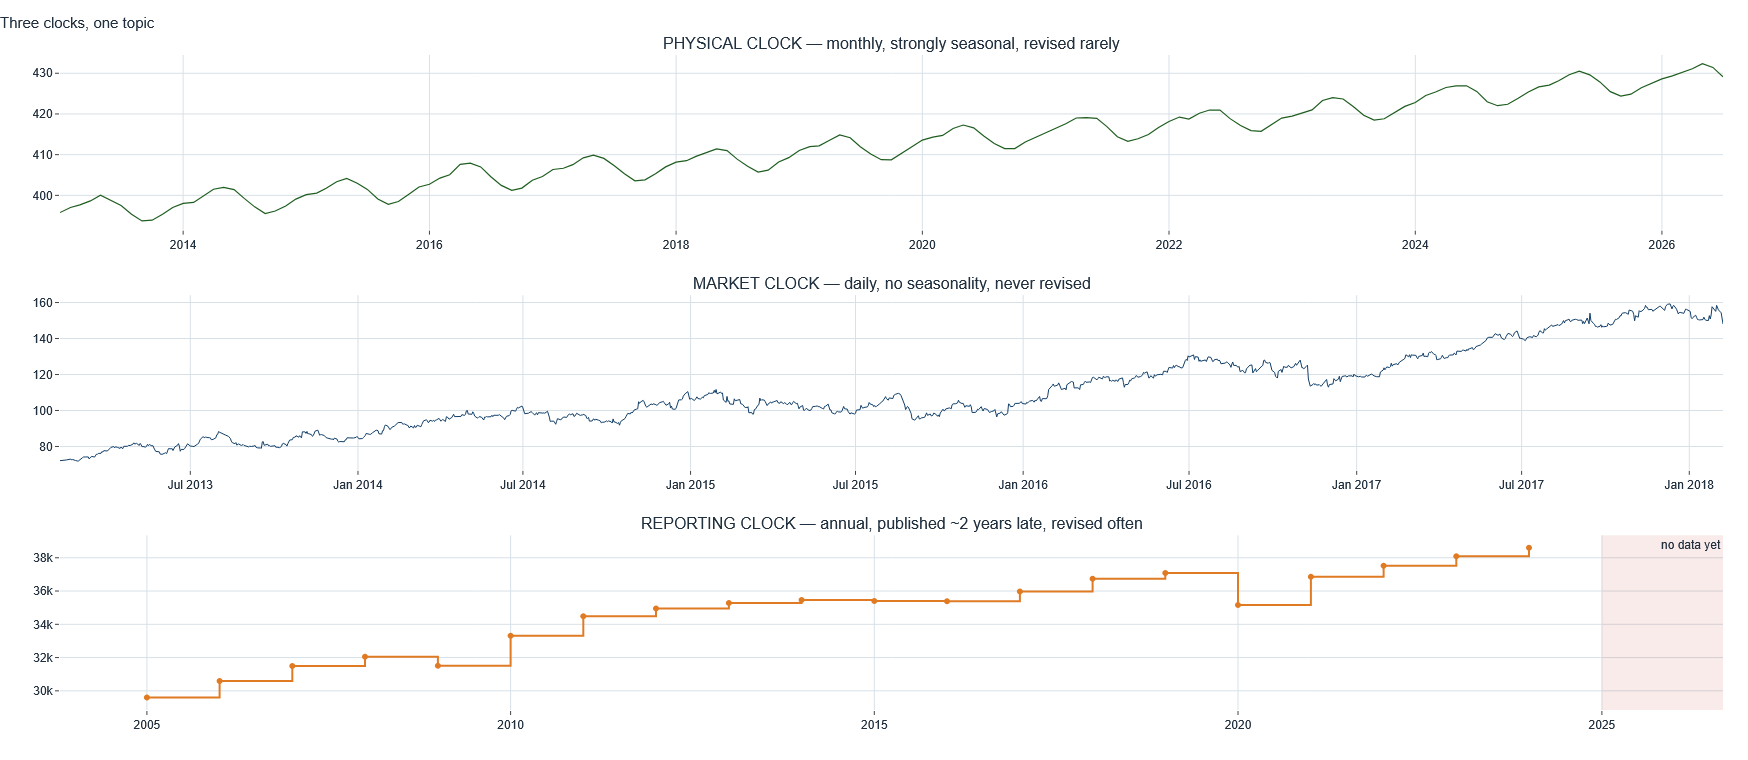

In [3]:
fig = make_subplots(rows=3, cols=1, vertical_spacing=0.10, subplot_titles=[
    "PHYSICAL CLOCK — monthly, strongly seasonal, revised rarely",
    "MARKET CLOCK — daily, no seasonality, never revised",
    "REPORTING CLOCK — annual, published ~2 years late, revised often"])

m = co2.loc["2013":]
fig.add_trace(go.Scatter(x=m.index, y=m.co2, line=dict(color=E.COLOURS["dark_green"], width=1.2),
                         name="Mauna Loa CO₂ (ppm)"), row=1, col=1)
fig.add_trace(go.Scatter(x=nee.index, y=nee.values, line=dict(color=E.COLOURS["blue"], width=1),
                         name="NEE close (US$)"), row=2, col=1)
w = world.loc[2005:]
fig.add_trace(go.Scatter(x=pd.to_datetime([f"{y}-01-01" for y in w.index]), y=w.values,
                         line=dict(color=E.COLOURS["orange"], width=2, shape="hv"),
                         mode="lines+markers", name="World CO₂ (Mt)"), row=3, col=1)
fig.add_vrect(x0="2025-01-01", x1="2026-09-01", fillcolor=E.COLOURS["red"], opacity=0.10,
              line_width=0, row=3, col=1, annotation_text="no data yet")
fig.update_layout(height=760, showlegend=False, title="Three clocks, one topic")
fig.show()

> **Exercise 1 (Core).** Pick a different utility from the panel — `XOM`, `DUK`,
> `SO` and `AES` are all in there. Does anything about the market-clock panel
> change? Now try to state, in one sentence, what would have to be true of a
> series for a seasonal model to be worth fitting to it.

---
## 2. Your data has a publication date

Here is the part that no standard time-series course covers. The OWID panel is
published from a public git repository, which means we can download the *same
file as it existed on four different dates* and compare them.

These are genuine historical commits. Nothing below is simulated.

In [4]:
vintages = {tag: E.load_owid_vintage(tag) for tag in ["2023", "2024", "2025", "2026"]}

for tag, df in vintages.items():
    last = int(df.query("country == 'World' and co2 == co2").year.max())
    published = pd.Timestamp(E.VINTAGE_DATES[tag])
    lag = published.year + published.dayofyear / 365 - last
    print(f"published {published:%Y-%m}  →  latest year available {last}   (lag {lag:.1f} years)")

published 2023-11  →  latest year available 2021   (lag 2.9 years)
published 2024-11  →  latest year available 2023   (lag 1.9 years)
published 2025-11  →  latest year available 2024   (lag 1.9 years)
published 2026-06  →  latest year available 2024   (lag 2.4 years)


Now the more uncomfortable question. Take a single year — say 2021 — and ask how
much its value changed between the November 2024 release and the current one.

The year 2021 was already three years in the past when the 2024 vintage was
published. Its emissions had happened. Nothing about the physical world changed.

In [5]:
YEAR = 2021
a = vintages["2024"].query(f"year == {YEAR}").set_index("country")["co2"]
b = vintages["2026"].query(f"year == {YEAR}").set_index("country")["co2"]

j = pd.concat([a.rename("nov_2024"), b.rename("jun_2026")], axis=1).dropna()
j = j[j.nov_2024 > 1.0]                      # drop micro-emitters, where % moves are noise
j["revision_pct"] = (j.jun_2026 - j.nov_2024) / j.nov_2024 * 100
r = j.revision_pct.abs()

print(f"countries with >1 Mt of emissions: {len(j)}")
print(f"  revised at all:        {(r > 0.001).mean() * 100:.0f}%")
print(f"  revised by over 1%:    {(r > 1).mean() * 100:.0f}%")
print(f"  median |revision|:     {r.median():.2f}%")
print(f"  95th percentile:       {r.quantile(0.95):.1f}%")

countries with >1 Mt of emissions: 195
  revised at all:        94%
  revised by over 1%:    38%
  median |revision|:     0.48%
  95th percentile:       11.9%


<details>
<summary><b>Show the maths: why the recent end is always the worst</b></summary>

National inventories are built from energy statistics that arrive in stages.
Early estimates lean on partial fuel-consumption data and modelled activity;
later releases substitute audited returns. So the revision to year $y$ observed
at vintage $v$ behaves roughly like a decaying function of $v - y$: large when
the observation is fresh, small once the underlying statistics have settled.

The practical consequence is unpleasant. The observations you most want to use
— the recent ones, closest to the decision — are the ones carrying the largest
expected revision. Any backtest that uses a single modern vintage silently
assigns settled, audited values to a period when only provisional ones existed.

</details>

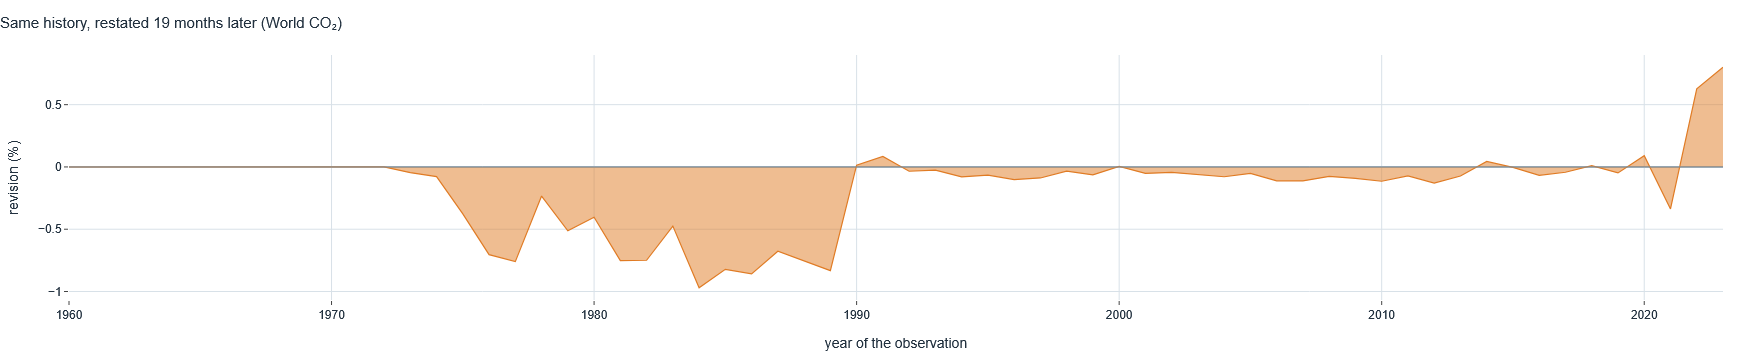

mean |revision|, 1960–2013:  0.216%
mean |revision|, 2019–2023:  0.381%


In [6]:
# Where does the churn actually live? Revision to World CO₂, by year of observation.
wa = vintages["2024"].query("country == 'World'").set_index("year")["co2"]
wb = vintages["2026"].query("country == 'World'").set_index("year")["co2"]
rev = ((wb - wa) / wa * 100).dropna().loc[1960:]

fig = go.Figure(go.Scatter(x=rev.index, y=rev.values, fill="tozeroy",
                           line=dict(color=E.COLOURS["orange"], width=1.2), name="revision"))
fig.add_hline(y=0, line_color=E.COLOURS["grey"], line_width=1)
fig.update_layout(title="Same history, restated 19 months later (World CO₂)",
                  xaxis_title="year of the observation", yaxis_title="revision (%)", height=360)
fig.show()

print(f"mean |revision|, 1960–2013:  {rev.loc[1960:2013].abs().mean():.3f}%")
print(f"mean |revision|, 2019–2023:  {rev.loc[2019:2023].abs().mean():.3f}%")

> **Exercise 2 (Core).** Repeat the country-level comparison for the 2023 vintage
> against the current one. Is the picture worse over the longer gap, or does most
> of the revision happen quickly and then settle?
>
> **Exercise 3 (Stretch).** Build a small "vintage panel": for a single country,
> a DataFrame indexed by observation year with one column per vintage. Then
> answer the question a portfolio manager would actually ask — *if I had run a
> decarbonisation screen in November 2024 using the data available then, how many
> countries would have crossed my threshold in the opposite direction under
> today's data?*

---
## 3. Reconciling the clocks — and the leak that hides in it

You have annual disclosed emissions and you want a monthly series. There is no
free lunch here: every method makes an assumption, and one of the popular ones
is straightforwardly invalid.

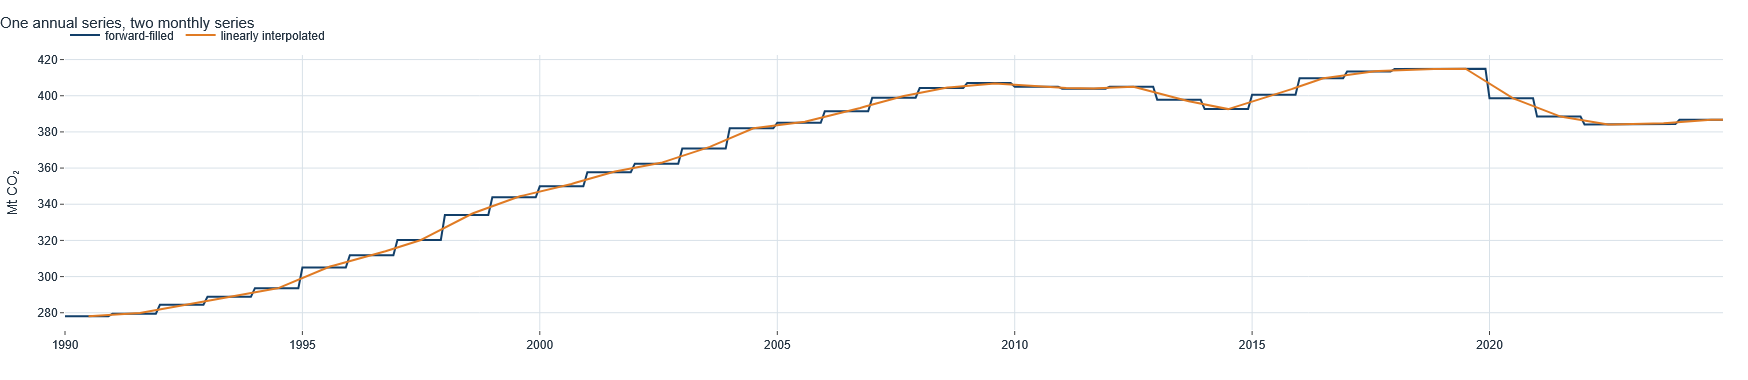

In [7]:
annual = aus.loc[1990:2024]

ff = E.annual_to_monthly(annual, how="ffill")           # repeat last known value
li = E.annual_to_monthly(annual, how="interpolate")     # straight line between years

fig = E.plot_series({"forward-filled": ff, "linearly interpolated": li},
                    title="One annual series, two monthly series",
                    ylab="Mt CO₂", height=380)
fig.show()

The interpolated line looks better. It is smoother, it has no artificial steps,
and it is the one most tutorials reach for.

It is also the one that cannot be used. To draw the value for January 2023 it
needs the 2024 observation — a number that did not exist until late 2025. Every
monthly row in that series contains information from its own future.

Let us make the leak explicit rather than argue about it.

In [8]:
# Linear interpolation places each annual figure at mid-year and draws a line
# between consecutive anchors. So a month in the SECOND half of year Y sits on
# the segment running from the Y anchor to the Y+1 anchor -- it depends on the
# year Y+1 figure, which is published roughly two years after that month.
#
# Rebuild the series as it could have been built at the end of 2023, when the
# 2024 figure did not yet exist, and compare.
truncated = E.annual_to_monthly(annual.loc[:2023], how="interpolate")

cmp = pd.DataFrame({
    "built with 2024 data (what you get)": li,
    "built without it (what was knowable)": truncated,
}).loc["2023-06-01":"2023-12-01"]
cmp["difference"] = cmp.iloc[:, 0] - cmp.iloc[:, 1]

print(cmp.round(2).to_string())
print(f"\nlargest difference in H2 2023: {cmp['difference'].abs().max():.2f} Mt")
print("Every non-zero row is a month whose value was computed from its own future.")

            built with 2024 data (what you get)  built without it (what was knowable)  difference
2023-06-01                              384.300                               384.300       0.000
2023-07-01                              384.320                               384.320       0.000
2023-08-01                              384.520                               384.320       0.200
2023-09-01                              384.730                               384.320       0.410
2023-10-01                              384.920                               384.320       0.610
2023-11-01                              385.130                               384.320       0.810
2023-12-01                              385.330                               384.320       1.010

largest difference in H2 2023: 1.01 Mt
Every non-zero row is a month whose value was computed from its own future.


> **Exercise 4 (Core).** The safe alternative is an *as-of* join: attach to each
> date the last value that had actually been **published** by then. Using
> `pd.merge_asof`, build a monthly series of Australian emissions where each
> month carries the figure that was publicly available at that time. Assume a
> 24-month publication lag. How much does it differ from the forward-filled
> version, and in which direction?

---
## 4. Decomposition, case 1: seasonality that is real

Mauna Loa CO₂ has a seasonal cycle with a mechanism you can name: Northern
Hemisphere plants draw down CO₂ through the growing season and release it as
vegetation decays. That test — *can I name the mechanism?* — is the one that
separates this section from the next.

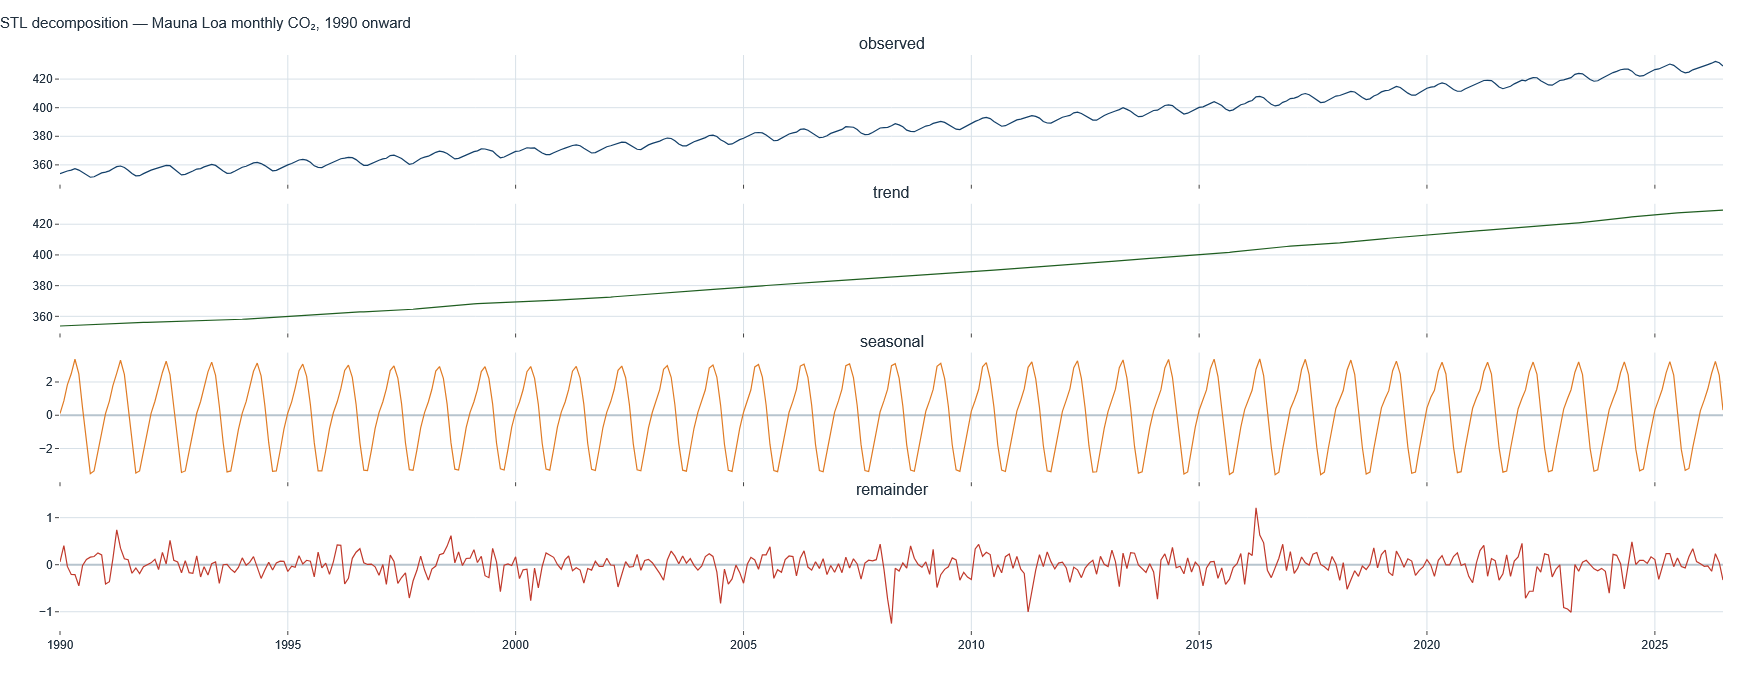

trend rise over the window : +75.4 ppm
seasonal peak-to-trough    : 6.7 ppm
remainder sd               : 0.26 ppm (4% of the seasonal amplitude)


In [9]:
y = co2["co2"].loc["1990":].dropna()
stl = STL(y, period=12, seasonal=13, robust=True).fit()

E.plot_stl(stl, title="STL decomposition — Mauna Loa monthly CO₂, 1990 onward").show()

amp = stl.seasonal.loc["2020":].max() - stl.seasonal.loc["2020":].min()
print(f"trend rise over the window : {stl.trend.iloc[-1] - stl.trend.iloc[0]:+.1f} ppm")
print(f"seasonal peak-to-trough    : {amp:.1f} ppm")
print(f"remainder sd               : {stl.resid.std():.2f} ppm "
      f"({stl.resid.std() / amp * 100:.0f}% of the seasonal amplitude)")

<details>
<summary><b>Show the maths: what the <code>seasonal</code> argument controls</b></summary>

STL runs an inner loop that alternates between estimating the seasonal and the
trend components using Loess smoothers. The `seasonal` argument is the span of
the Loess smoother applied **across years within a given month position** — it
is not the period.

Large `seasonal` forces every January to look like every other January: a rigid,
near-constant seasonal shape. Small `seasonal` lets the January effect drift
over time. `period` is separate and must be the true cycle length (12 here).

For ESG series the drift matters. A firm that installs rooftop solar genuinely
changes its seasonal profile, and a rigid seasonal component would push that real
change into the trend, where it looks like decarbonisation.

</details>

In [10]:
# How much does the seasonal smoothing choice matter here?
for s in [7, 13, 31, 101]:
    fit = STL(y, period=12, seasonal=s, robust=True).fit()
    a = fit.seasonal.loc["2020":].max() - fit.seasonal.loc["2020":].min()
    drift_ = fit.seasonal.loc["2020":].max() - fit.seasonal.loc["1991":"1995"].max()
    print(f"seasonal={s:>4}   amplitude {a:.2f} ppm   change in peak since early 1990s {drift_:+.2f} ppm")

seasonal=   7   amplitude 6.79 ppm   change in peak since early 1990s +0.14 ppm
seasonal=  13   amplitude 6.69 ppm   change in peak since early 1990s -0.07 ppm
seasonal=  31   amplitude 6.81 ppm   change in peak since early 1990s +0.24 ppm
seasonal= 101   amplitude 6.70 ppm   change in peak since early 1990s +0.19 ppm


On *this* series the choice barely registers — the amplitude moves by about
0.1 ppm across a fourteen-fold change in the smoothing window. That is not a
failed demonstration; it is a finding. The Mauna Loa seasonal cycle is
genuinely stable, so nothing you do to the smoother can make it drift.

Expect the opposite on a corporate series, where an acquisition or a new solar
installation changes the seasonal profile partway through the sample. That is
where the parameter starts to matter, and where a rigid seasonal component
would push a real change into the trend and call it decarbonisation.

---
## 5. Decomposition, case 2: seasonality your pipeline invented

Now run exactly the same tool on the forward-filled Australian series. STL will
not complain. It will return a trend, a seasonal component and a remainder, all
looking perfectly respectable.

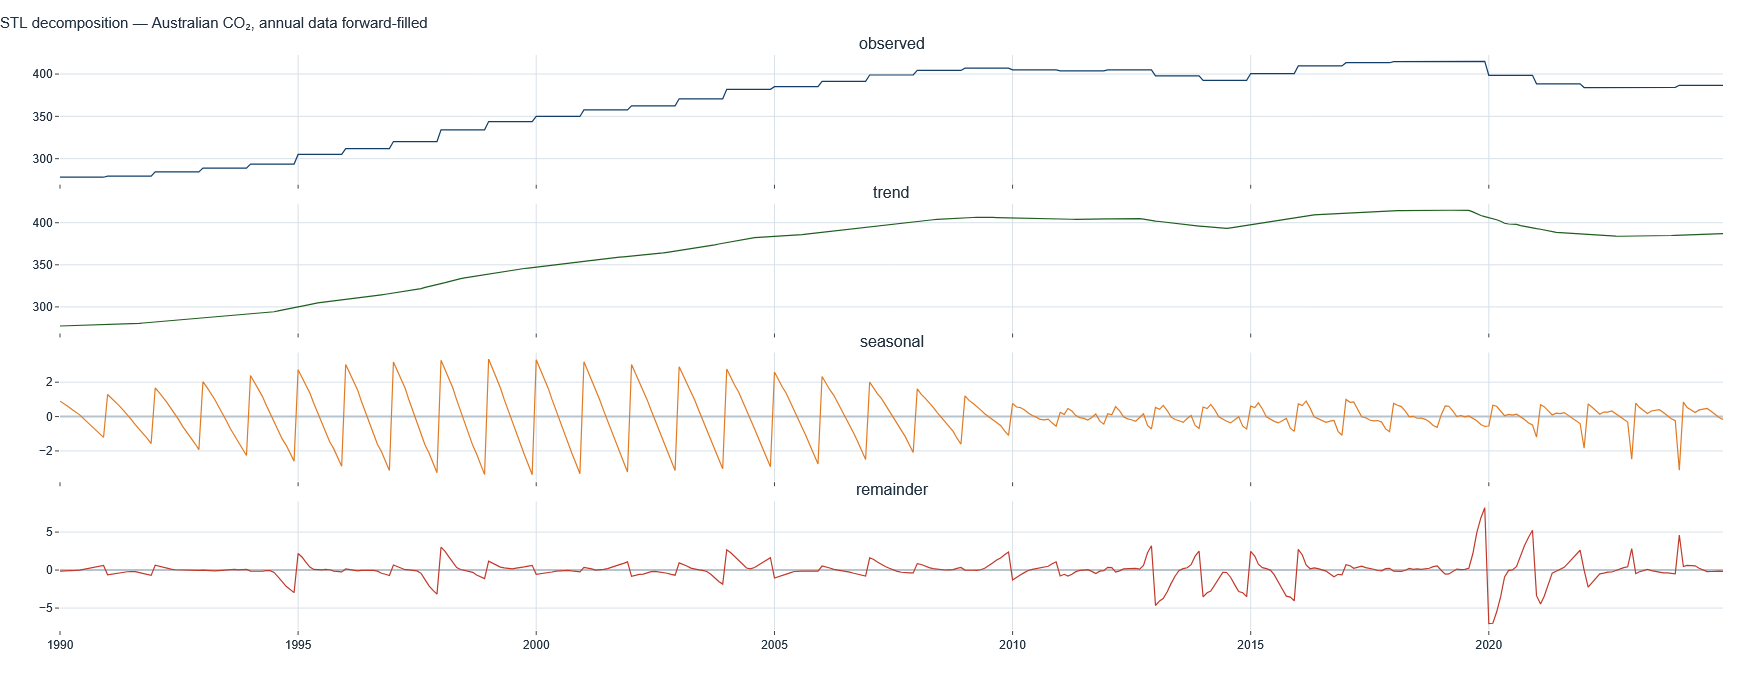

In [11]:
stl_ff = STL(ff, period=12, seasonal=13, robust=True).fit()
E.plot_stl(stl_ff, title="STL decomposition — Australian CO₂, annual data forward-filled").show()

months changing by exactly zero : 385 of 419  (91.9%)
extracted seasonal amplitude    : 6.74 Mt (1.8% of the level)


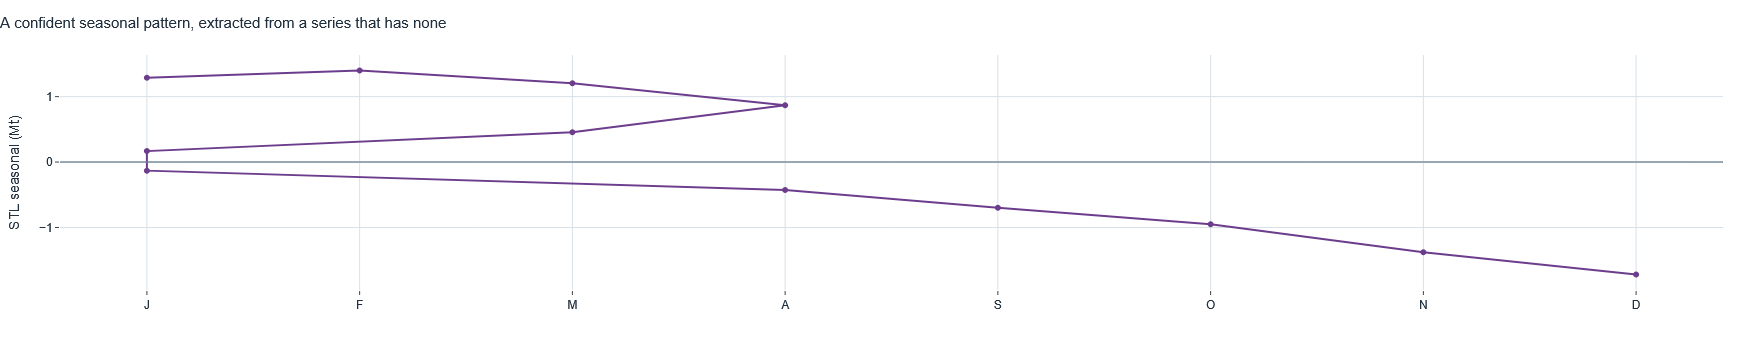

In [12]:
d = ff.diff()
n_zero = int((d.abs() < 1e-9).sum())
n_tot = int(d.notna().sum())
seas = stl_ff.seasonal
by_month = seas.groupby(seas.index.month).mean()

print(f"months changing by exactly zero : {n_zero} of {n_tot}  ({n_zero / n_tot * 100:.1f}%)")
print(f"extracted seasonal amplitude    : {seas.max() - seas.min():.2f} Mt "
      f"({(seas.max() - seas.min()) / ff.mean() * 100:.1f}% of the level)")

fig = go.Figure(go.Scatter(x=list("JFMAMJJASOND"), y=by_month.values, mode="lines+markers",
                           line=dict(color=E.COLOURS["purple"], width=2)))
fig.add_hline(y=0, line_color=E.COLOURS["grey"], line_width=1)
fig.update_layout(title="A confident seasonal pattern, extracted from a series that has none",
                  yaxis_title="STL seasonal (Mt)", height=340)
fig.show()

**Nine months in ten change by exactly zero**, and all the movement lands in
January — because that is when the annual figure is stamped, not because
Australian emissions are seasonal.

The output looks exactly as credible as Case 1. That is the point worth taking
away: **the method cannot tell you which case you are in.** You have to know
where the series came from.

The one-line check below would have caught this before any modelling started.

In [13]:
def flat_share(s):
    "Fraction of periods that change by exactly zero — the cheapest diagnostic there is."
    d = s.diff().dropna()
    return float((d.abs() < 1e-9).mean())

for name, s in {"Mauna Loa (monthly)": y,
                "Australia (annual → monthly, ffill)": ff,
                "Australia (annual, as published)": annual.astype(float)}.items():
    print(f"{name:<40} {flat_share(s) * 100:5.1f}% flat")

Mauna Loa (monthly)                        0.0% flat
Australia (annual → monthly, ffill)       91.9% flat
Australia (annual, as published)           0.0% flat


> **Exercise 5 (Core).** Run the same forward-fill and STL on a different country
> and confirm the artefact reproduces. Then run it on the *linearly interpolated*
> version instead. Does interpolation remove the artefact, create a different one,
> or both?
>
> **Exercise 6 (Stretch).** `flat_share` catches step-interpolation. It does
> **not** catch linear interpolation, which changes every month. Write a second
> diagnostic that does — one idea is to look at the distribution of second
> differences, which is near-zero within a year for a linearly interpolated
> series and not for a genuine one.

---
## 6. The frequency domain

Decomposition *assumed* the period was 12 and handed you a seasonal component.
The periodogram lets you ask what the period is instead of asserting it — and,
more usefully, **how much of the variance actually sits there**.

In [14]:
# Three clocks, three spectra. Note the different detrending choices.
A = co2["co2"].loc["1990":"2024"]            # 420 months = 35 whole years
B = ff                                       # the forward-filled artefact
Cc = np.log(nee).diff().dropna()             # daily log returns

specs = {
    "Mauna Loa CO₂ (monthly)":        E.periodogram(A.values, detrend="quadratic"),
    "Australia CO₂ (ffill, monthly)": E.periodogram(B.values, detrend="quadratic"),
    "NEE log returns (daily)":        E.periodogram(Cc.values, detrend="mean"),
}

for name, (f, p) in specs.items():
    peaks = E.top_peaks(f, p, k=3)
    share10 = np.sort(p / p.sum())[-10:].sum()
    print(f"{name}")
    print(f"   top periods : {', '.join(f'{v:.1f}' for v in peaks.period)}")
    print(f"   top bin     : {peaks.share_of_var.iloc[0] * 100:5.1f}% of variance")
    print(f"   top 10 bins : {share10 * 100:5.1f}% of variance\n")

Mauna Loa CO₂ (monthly)
   top periods : 12.0, 6.0, 84.0
   top bin     :  86.8% of variance
   top 10 bins :  97.8% of variance

Australia CO₂ (ffill, monthly)
   top periods : 105.0, 210.0, 84.0
   top bin     :  37.7% of variance
   top 10 bins :  89.2% of variance

NEE log returns (daily)
   top periods : 7.2, 2.6, 3.8
   top bin     :   1.5% of variance
   top 10 bins :   8.2% of variance



Do not compare the height of the tallest peak across these three. Two things
matter, and you need both.

**Concentration.** The CO₂ series puts 97.8% of its variance in ten frequency
bins; the return series manages 8.2%. That gap is what "no exploitable pattern"
looks like in the frequency domain.

**But concentration alone is not enough** — and the middle row proves it. The
forward-filled series is also highly concentrated (89.2% in ten bins), yet it
has no structure worth modelling. Its variance piles up at periods of 105 and
210 months, which are simply the length of the sample and half of it. That is
the trend, not a cycle.

So the test is concentration **at a period you can name a mechanism for**. Twelve
months on an atmospheric series passes. One hundred and five months on anything
is the spectrum telling you it found the trend you failed to remove.

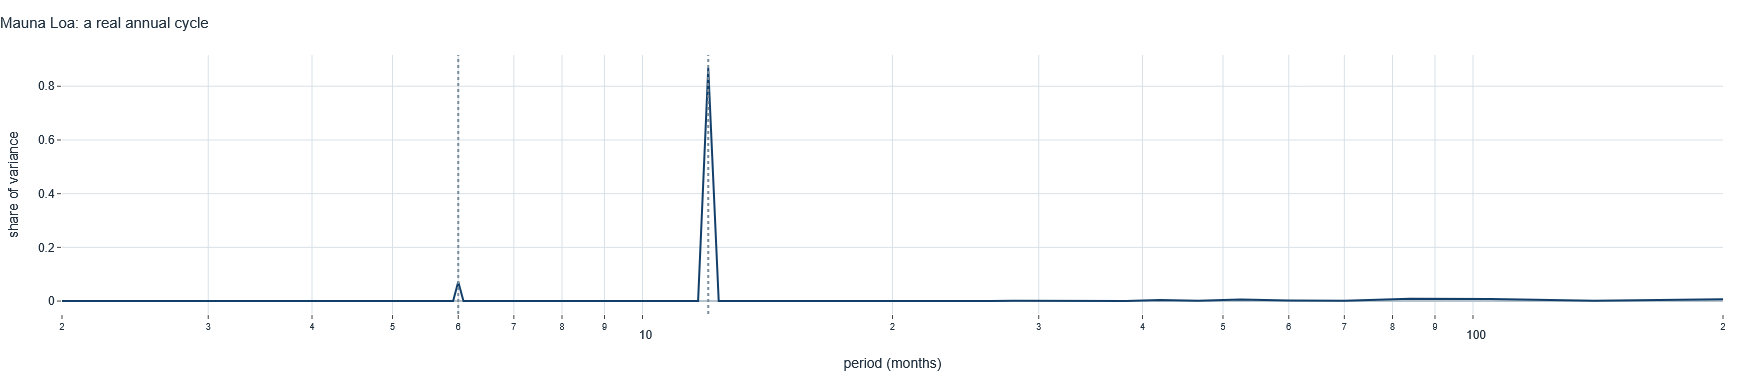

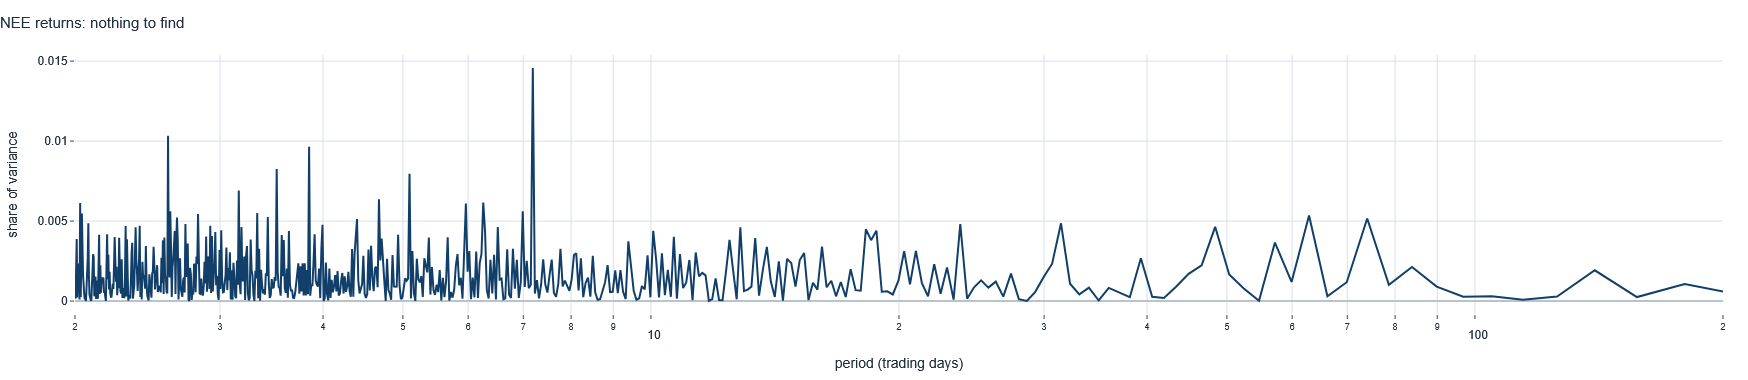

In [15]:
f, p = specs["Mauna Loa CO₂ (monthly)"]
E.plot_periodogram(f, p, title="Mauna Loa: a real annual cycle",
                   xlab="period (months)", mark=(12, 6), xmax=200).show()

f, p = specs["NEE log returns (daily)"]
E.plot_periodogram(f, p, title="NEE returns: nothing to find",
                   xlab="period (trading days)", xmax=200).show()

> **Exercise 7 (Core).** Plot the spectrum of the forward-filled Australian series
> yourself. It does **not** show a spurious peak at 12 months. Explain what it
> shows instead, and why step-interpolation smears power to long periods rather
> than manufacturing a fake annual cycle.

---
## 7. Resolution: why your period comes out at 12.06 months

The DFT can only see frequencies $j/T$. If 12 is not one of them, the annual
cycle's power splits across the two nearest bins and you report a period that is
an artefact of how long your sample happens to be.

In [16]:
full = co2["co2"].dropna()               # whatever length the data happens to be
whole = full.iloc[len(full) % 12:]       # trimmed to a whole number of years

for label, s in [("full sample", full), ("trimmed to whole years", whole)]:
    f, p = E.periodogram(s.values, detrend="quadratic")
    top = E.top_peaks(f, p, k=1)
    share = (p / p.sum()).max()
    print(f"{label:<24} T = {len(s):>4}   peak at {top.period.iloc[0]:6.2f} months   "
          f"top bin holds {share * 100:4.1f}% of variance")

full sample              T =  821   peak at  12.07 months   top bin holds 40.6% of variance
trimmed to whole years   T =  816   peak at  12.00 months   top bin holds 80.2% of variance


<details>
<summary><b>Show the maths: spectral leakage</b></summary>

The DFT of a length-$T$ sample evaluates the spectrum only at the Fourier
frequencies $f_j = j/T$. A sinusoid whose true frequency falls between two of
these is equivalent to multiplying an infinite sinusoid by a rectangular window
of length $T$. In the frequency domain that multiplication becomes convolution
with the window's transform, a Dirichlet kernel whose sidelobes decay slowly.
The result is that power "leaks" into neighbouring bins.

When $T$ is an exact multiple of the period, the sinusoid completes a whole
number of cycles in the window, the kernel's zeros land on every other Fourier
frequency, and the leakage vanishes. When it is not, it does not.

Two fixes: choose $T$ as a whole number of cycles (free, and available whenever
you control the sample), or apply a taper such as a Hann window, which trades a
slightly wider main lobe for far lower sidelobes. `scipy.signal.welch` does the
latter for you.

</details>

Trimming a handful of observations changes nothing about the data and a great
deal about what you would have reported. Whenever you are hunting a known
period, use a whole number of cycles.

**Your numbers will not match the lecture slides here, and that is the point.**
The slides were built when the series ended in June 2026 ($T = 820$, peak at
12.06 months). Your download runs one month further, so $T$ has changed and with
it the reported period and the concentration. Nothing about the atmosphere
changed between those two runs. If a result moves when one observation arrives,
it was never a property of the data.

---
## 8. From spectrum to features

This is the step that makes the whole spectral detour pay. The periodogram said
"12 months". So build sine and cosine pairs at that period and hand them to a
regression — and let the data tell you how many pairs you need.

In [17]:
yv = A.values
t = np.arange(len(yv))
resid = yv - np.polyval(np.polyfit(t, yv, 2), t)     # strip the trend first

def fit_harmonics(K):
    X = np.column_stack([np.ones(len(t))] +
                        [fn(2 * np.pi * k * t / 12)
                         for k in range(1, K + 1) for fn in (np.sin, np.cos)])
    beta, *_ = np.linalg.lstsq(X, resid, rcond=None)
    fitted = X @ beta
    return fitted, 1 - np.var(resid - fitted) / np.var(resid)

for K in range(1, 7):
    _, r2 = fit_harmonics(K)
    print(f"K = {K}   {2 * K:>2} features   R² = {r2:.4f}")

K = 1    2 features   R² = 0.8683
K = 2    4 features   R² = 0.9401
K = 3    6 features   R² = 0.9403
K = 4    8 features   R² = 0.9408
K = 5   10 features   R² = 0.9409
K = 6   12 features   R² = 0.9410


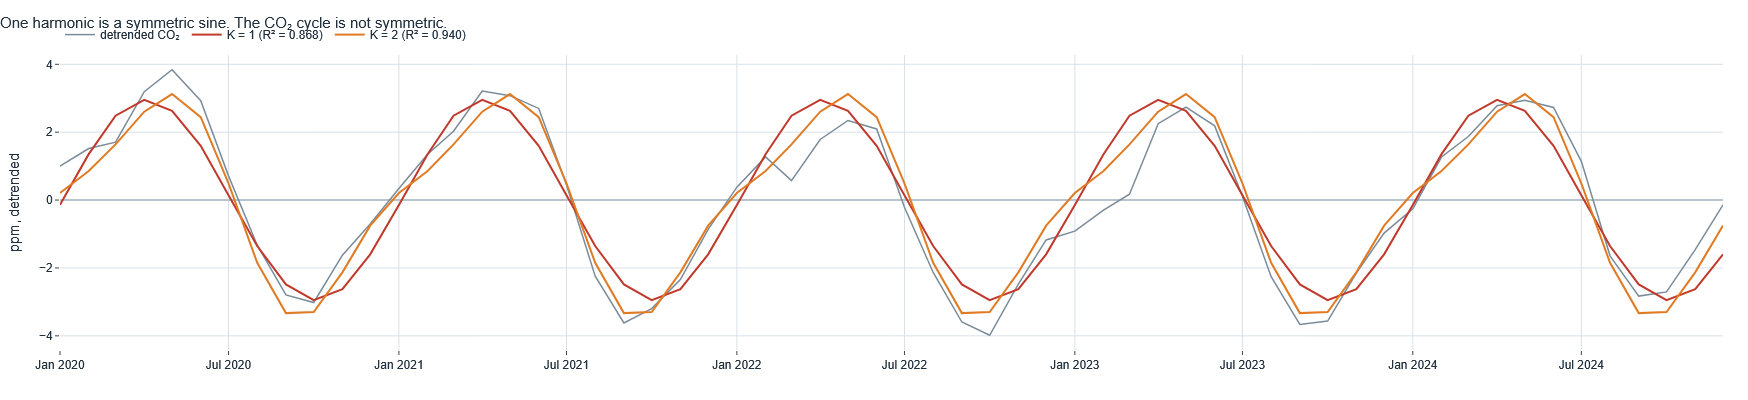

In [18]:
show = slice(len(yv) - 60, len(yv))
fig = go.Figure()
fig.add_trace(go.Scatter(x=A.index[show], y=resid[show], name="detrended CO₂",
                         line=dict(color=E.COLOURS["grey"], width=1.5)))
for K, colour in [(1, E.COLOURS["red"]), (2, E.COLOURS["orange"])]:
    fitted, r2 = fit_harmonics(K)
    fig.add_trace(go.Scatter(x=A.index[show], y=fitted[show],
                             name=f"K = {K} (R² = {r2:.3f})",
                             line=dict(color=colour, width=2)))
fig.update_layout(title="One harmonic is a symmetric sine. The CO₂ cycle is not symmetric.",
                  yaxis_title="ppm, detrended", height=400)
fig.show()

The jump from $K=1$ to $K=2$ is large; everything after it is noise. The CO₂
cycle rises slowly and falls fast, and a single sine wave cannot represent that
asymmetry — the second harmonic can.

**Four features is the right answer, and the data told you so.** No
cross-validation was required. Carry `K = 2` into notebook 6b.

> **Exercise 8 (Core).** Use `E.fourier_terms` to build the same feature matrix
> and confirm you get the same $R^2$. Then repeat the exercise on the NEE return
> series. What value of $K$ does the data support there, and what does that tell
> you about fitting a seasonal model to returns?
>
> **Exercise 9 (Stretch).** Corporate disclosures and controversies arrive at
> irregular times, and the DFT assumes even sampling. Resampling them onto a
> regular grid is precisely the Section 5 artefact. Use
> `scipy.signal.lombscargle` on an unevenly sampled series — you can simulate
> the sampling by dropping a random 40% of the CO₂ months — and check whether it
> still recovers the 12-month period. Assess significance by permutation: shuffle
> the values against the timestamps many times and compare your peak against the
> resulting null distribution.

---
## What to carry into 6b

1. **CO₂ is on a physical clock**: monthly, genuinely seasonal at 12 months with
   a second harmonic, minimal revision. It is an unusually well-behaved series,
   which is exactly why we forecast it first.
2. **Annual reported data forward-filled to monthly is not a monthly series.**
   Check `flat_share` before you model anything.
3. **`K = 2` Fourier terms at period 12** is the seasonal feature set, and it was
   chosen by the data rather than by search.
4. **Quadratic detrending** is needed for CO₂ because the growth rate itself rises.
   Remember this when you decide how to make the series stationary in 6b.